# Customer Purchase Behaviour Analysis Using Cohort & RFM

### The goal: This project helps an online retail store better understand its customers. By looking at past sales data, the project answers two main questions: how long do customers keep coming back, and who are our most valuable shoppers? This allows the business to target the right people with the right promotions.

## Table of contents
1. [Data Cleaning & Preprocessing](#1-data-cleaning--preprocessing)
2. [Cohort Analysis & Customer Retention Heatmap](#2-cohort-analysis--customer-retention-heatmap)
3. [RFM Customer Segmentation Model](#3-rfm-customer-segmentation-model)

## 1. Data Cleaning & Preprocessing 
### Goal: To transform raw, messy transaction records into a reliable and accurate dataset by handling missing values, negative quantities, and errors. 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [2]:
df = pd.read_excel("Online Retail.xlsx")

In [3]:
# Force the entire column to be string type
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df['StockCode'] = df['StockCode'].astype(str)
df['Description'] = df['Description'].astype(str)

In [4]:
# Save to Parquet
df.to_parquet('online_retail1.parquet',
                   index=False)

In [5]:
# Load raw data
raw_df = pd.read_parquet('online_retail1.parquet')
raw_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  541909 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
raw_df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
# Drop rows with missing CustomerID — these sales can't be attributed
#    to a customer, so they're unusable for customer-level analysis.
raw_df = raw_df.dropna(subset='CustomerID')

In [9]:
raw_df[(raw_df['CustomerID']).isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [10]:
# Remove returns (negative Quantity). These represent refunds/cancellations,
#    not completed purchases, and would distort revenue and frequency metrics.
(raw_df['Quantity']<0).sum()

np.int64(8905)

In [11]:
raw_df = raw_df[raw_df['Quantity']>0]

In [12]:
(raw_df['Quantity']<0).sum()

np.int64(0)

In [13]:
# Remove exact duplicate rows.
raw_df.duplicated().sum()

np.int64(5192)

In [14]:
raw_df = raw_df.drop_duplicates()

In [15]:
raw_df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [16]:
# Calculate revenue per line item
raw_df['TotalPrice'] = raw_df['Quantity'] * raw_df['UnitPrice']

In [17]:
raw_df.TotalPrice.min()

np.float64(0.0)

In [18]:
raw_df['Quantity'].dtype

dtype('int64')

In [19]:
(raw_df['UnitPrice']==0.0).sum()

np.int64(40)

The dataset contained transactions with a UnitPrice of 0. These likely represent promotional or complimentary items. Since these transactions contribute zero revenue, they were excluded from revenue-based analyses such as Customer Lifetime Value (CLV)

In [20]:
# Exclude zero-price transactions (promotional/complimentary items).
#    These generate no revenue, so they're excluded from revenue-based
#    analyses such as Customer Lifetime Value.
sales_df = raw_df[raw_df['UnitPrice'] > 0].copy()

In [21]:
sales_df[sales_df['TotalPrice'] == sales_df['TotalPrice'].min()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
157195,550193,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-04-15 09:27:00,0.001,13952.0,United Kingdom,0.001
279045,561226,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-07-26 10:13:00,0.001,15618.0,United Kingdom,0.001
359871,568200,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-09-25 14:58:00,0.001,16198.0,United Kingdom,0.001
361741,568375,BANK CHARGES,Bank Charges,1,2011-09-26 17:01:00,0.001,13405.0,United Kingdom,0.001


In [22]:
# Cast CustomerID to int (was float64 due to earlier NaNs) so it
#    imports cleanly into a PostgreSQL INTEGER column.
sales_df['CustomerID'] = sales_df['CustomerID'].astype(int)

In [23]:
sales_df.to_csv("cleaned_retail.csv", index=False)

In [24]:
print(f"Final row count: {len(sales_df)}")
print(f"Unique customers: {sales_df['CustomerID'].nunique()}")

Final row count: 392692
Unique customers: 4338


## 2. Cohort Analysis & Customer Retention Heatmap
### Goal: To track customer loyalty over time and visually identify exactly when shoppers stop returning to the store.

In [25]:
cnxn_string = ("postgresql+psycopg2://{username}"
               "@{host}:{port}/{database}")

In [26]:
engine = create_engine(cnxn_string.format(
    username = "postgres",
    host = "localhost",
    port = 5432,
    database = "online_retail"))

In [27]:
with open("sql/cohort_analysis.sql") as f:
    cohort_query = f.read()

In [28]:
cohort_df = pd.read_sql_query(cohort_query, engine)

In [29]:
cohort_df.head()

,cohort_month,cohort_index,active_customers
0,2010-12-01,0.0,885
1,2010-12-01,1.0,324
2,2010-12-01,2.0,286
3,2010-12-01,3.0,340
4,2010-12-01,4.0,321


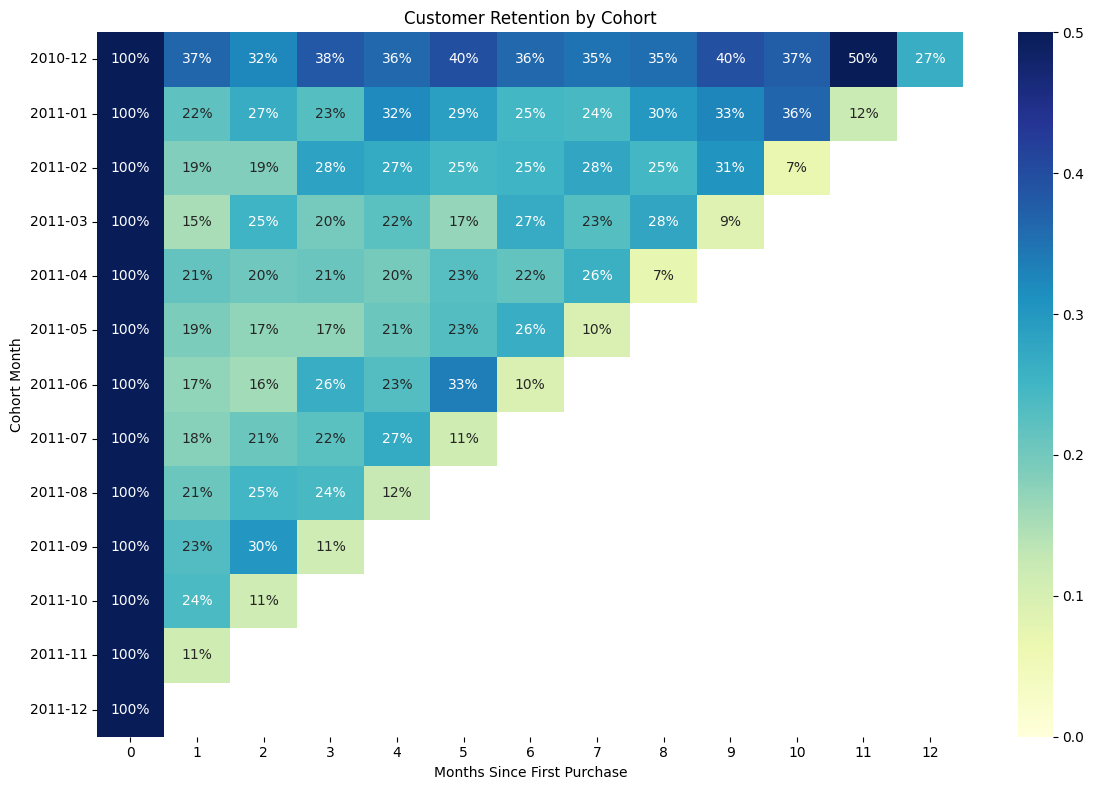

In [30]:
# Pivot into a cohort_month x cohort_index matrix
cohort_matrix = cohort_df.pivot(
    index='cohort_month', 
    columns='cohort_index', 
    values='active_customers'
)

# Convert raw counts to retention percentages relative to Month 0 size
cohort_sizes = cohort_matrix.iloc[:, 0]
retention_matrix = cohort_matrix.divide(cohort_sizes, axis=0)

# Clean up axis labels
retention_matrix.index = pd.to_datetime(retention_matrix.index).strftime('%Y-%m')
retention_matrix.columns = retention_matrix.columns.astype(int)

# Plot heatmap
plt.figure(figsize=(12, 8))
plt.title('Customer Retention by Cohort')
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='YlGnBu', vmin=0.0, vmax=0.5)
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.tight_layout()
plt.savefig('images/retention_heatmap.png', dpi=150)
plt.show()

### Interpretation
Retention drops off sharply after the first month for every cohort - most fall from 100% to somewhere in the 15-25% range by month 1 and hover in that band from there, meaning the majority of customers are one-time or occasional buyers rather than repeat purchasers.   
The **December 2010 cohort** stands out: it's the largest and earliest cohort, and it retains noticeably better than later ones, holding in the 35-40% range through most of the year and spiking to 50% at month 11. That's likely a seasonal effect - customers acquired at the start of the holiday shopping season returning for the following year's holiday season - rather than a sign this cohort is inherently more loyal.   
Customers who joined later in 2011 (like March-May) tend to come back less often than the customers who joined right at the start (December 2010). But there's a catch: we have less data for these newer groups - fewer customers, and less time to watch them - so these numbers could bounce around more and shouldn't be trusted as firmly as the December numbers.   
**Takeaway:** The biggest drop happens right after a customer's first purchase - most people who don't come back, stop coming back within the first month. So if we want customers to stick around longer (and spend more over time), the best place to focus effort is on that first month: things like a follow-up email, a discount on their next order, or a reminder-anything that gets them to buy a second time before they drift away. 

## 3. RFM Customer Segmentation Model
### Goal: Segment customers based on purchasing behaviour to support targeted marketing campaigns and provide a foundation for future predictive models. 

In [31]:
with open("sql/rfm_analysis.sql") as f:
    rfm_query = f.read()

In [32]:
rfm_df = pd.read_sql_query(rfm_query, engine)

In [33]:
rfm_df.head()

,customerid,recency,frequency,monetary_value
0,12346,326.0,1,77183.60
1,12347,2.0,7,4310.00
2,12348,75.0,4,1797.24
3,12349,19.0,1,1757.55
4,12350,310.0,1,334.40


In [34]:
# Score Recency (Lower days = better score = 4)
r_labels = range(4, 0, -1)
rfm_df['R_Score'] = pd.qcut(rfm_df['recency'], q=4, labels=r_labels)

In [35]:
# Score Frequency and Monetary (Higher = better = 4)
f_labels = range(1, 5)
m_labels = range(1, 5)

In [36]:
# I used rank(method='first') to handle ties in order counts
rfm_df['F_Score'] = pd.qcut(rfm_df['frequency'].rank(method='first'),
                            q=4, labels=f_labels)
rfm_df['M_Score'] = pd.qcut(rfm_df['monetary_value'],
                            q=4, labels=f_labels)

In [37]:
rfm_df.head()

,customerid,recency,frequency,monetary_value,R_Score,F_Score,M_Score
0,12346,326.0,1,77183.60,1,1,4
1,12347,2.0,7,4310.00,4,4,4
2,12348,75.0,4,1797.24,2,3,4
3,12349,19.0,1,1757.55,3,1,4
4,12350,310.0,1,334.40,1,1,2


In [38]:
# Combine into a segment string (e.g. "444") and a total score
rfm_df['RFM_Segment'] = (
    rfm_df['R_Score'].astype(str) +
    rfm_df['F_Score'].astype(str) +
    rfm_df['M_Score'].astype(str)
)
rfm_df['RFM_Score'] = rfm_df[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

In [39]:
rfm_df.head()

,customerid,recency,frequency,monetary_value,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,12346,326.0,1,77183.60,1,1,4,114,6
1,12347,2.0,7,4310.00,4,4,4,444,12
2,12348,75.0,4,1797.24,2,3,4,234,9
3,12349,19.0,1,1757.55,3,1,4,314,8
4,12350,310.0,1,334.40,1,1,2,112,4


In [40]:
def assign_persona(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']

    # Bought recently AND buy often
    if r >= 3 and f >= 3:
        return 'Champions'
    # Rarely buy, but spend a lot when they do
    elif f <= 2 and m >= 3:
        return 'Big Spenders'
    # Used to buy often, but haven't visited in a long time
    elif r <= 2 and f >= 3:
        return 'At Risk'
    # Haven't bought in a long time AND rarely bought
    elif r == 1 and f == 1:
        return 'Lost Customers'
    # Bought recently, but only a few times
    elif r >= 3 and f <= 2:
        return 'New Customers'
    else:
        return 'Typical Customers'

In [41]:
rfm_df['Persona'] = rfm_df.apply(assign_persona, axis=1)

In [42]:
rfm_df.to_csv('rfm_segments.csv', index=False)

In [43]:
print("Analysis completed successfully.")
print(f"Clean transactions: {len(sales_df):,}")
print(f"Customers analyzed: {rfm_df.shape[0]:,}")

Analysis completed successfully.
Clean transactions: 392,692
Customers analyzed: 4,338
